In [ ]:
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys
import subprocess
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
PROJECT_ROOT = os.environ.get("PROJECT_ROOT")
PYTHON_IO_ENCODING = os.environ.get("PYTHON_IO_ENCODING")
sys.path.insert(0, str(Path(os.environ.get("PROJECT_ROOT", "."))))
from src.data_preprocessing.plot_bounds import plot_image_with_bounds

### **Mask creation**

Image dimensions: 3000x1995


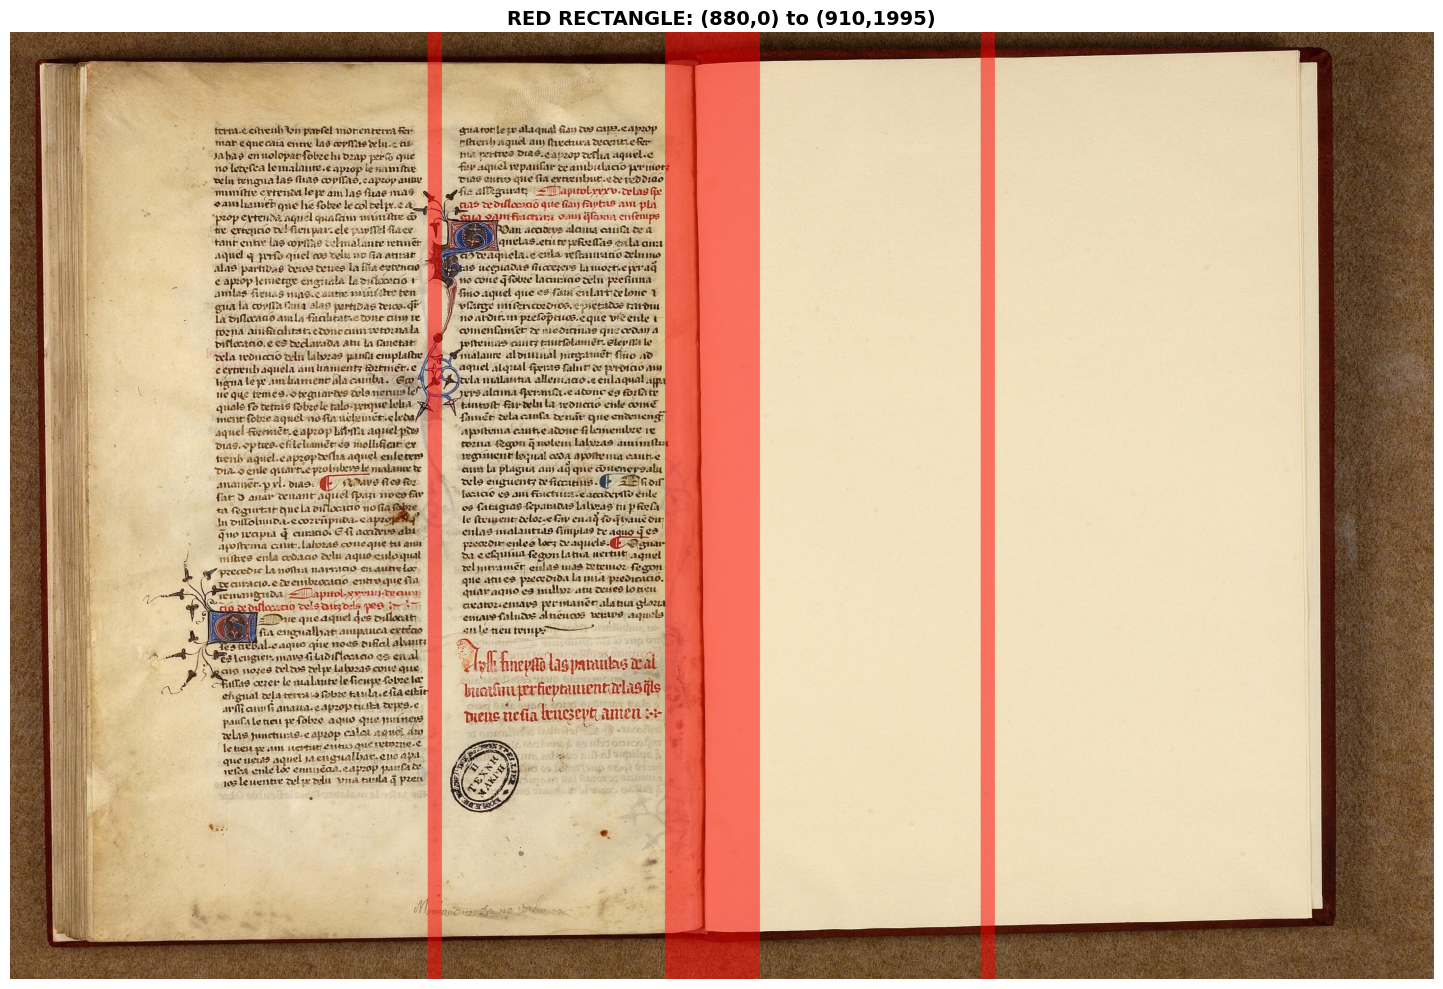

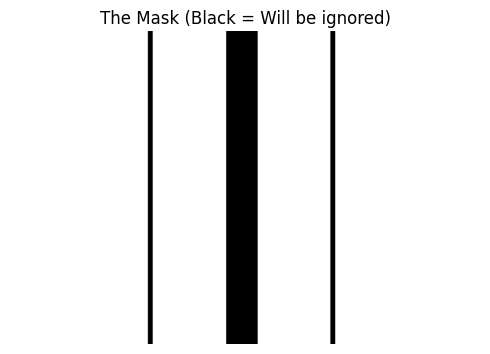

True

In [ ]:
# 1. Load image
#input_path = os.path.join(PROJECT_ROOT, "data", "raw", "original_manuscript", "reproduction14453_100", "8 - f. 003v - 004.jpg")
#input_path = os.path.join(PROJECT_ROOT, "data", "raw", "original_manuscript", "reproduction14453_100", "27 - f. 022v - 023.jpg") ->>> mask doesnt work well here, text is too close to the edge
input_path = os.path.join(PROJECT_ROOT, "data", "raw", "original_manuscript", "reproduction14453_100", "75 - f. 070v - garde.jpg")

img = cv2.imread(input_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]

print(f"Image dimensions: {w}x{h}")

# 2. Create a SIMPLE mask with a LARGE, VISIBLE rectangle
mask = np.ones((h, w), dtype=np.uint8) * 255  # White = 255

# Draw a BIG rectangle that's impossible to miss
# Adjust these coordinates based on your image
x1_1, y1_1 = 880,0
x2_1, y2_1 = 910,1995

x1_2, y1_2 = 1380,0
x2_2, y2_2 = 1580,1995

x1_3, y1_3 = 2045,0
x2_3, y2_3 = 2075,1995

cv2.rectangle(mask, (x1_1, y1_1), (x2_1, y2_1), 0, thickness=-1)
cv2.rectangle(mask, (x1_2, y1_2), (x2_2, y2_2), 0, thickness=-1)
cv2.rectangle(mask, (x1_3, y1_3), (x2_3, y2_3), 0, thickness=-1)

# 3. Create overlay using SIMPLEST method
# Make a copy of the image
overlay_img = img_rgb.copy()

# Color the masked area RED directly
overlay_img[y1_1:y2_1, x1_1:x2_1] = [255, 0, 0]  # Pure red in RGB
overlay_img[y1_2:y2_2, x1_2:x2_2] = [255, 0, 0]  # Pure red in RGB
overlay_img[y1_3:y2_3, x1_3:x2_3] = [255, 0, 0]  # Pure red in RGB

# 4. Blend using alpha compositing
alpha = 0.5  # 50% transparency
blended = cv2.addWeighted(overlay_img, alpha, img_rgb, 1-alpha, 0)

# 5. Display
plt.figure(figsize=(15, 10))
plt.imshow(blended)
plt.axis('off')
plt.title(f"RED RECTANGLE: ({x1_1},{y1_1}) to ({x2_1},{y2_1})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Also show the mask itself to verify
plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap='gray')
plt.title("The Mask (Black = Will be ignored)")
plt.axis('off')
plt.tight_layout()
plt.show()

# 5. SAVE as PNG (lossless, preserves exact 0/255 values)
#mask = cv2.imread("mask.png", cv2.IMREAD_GRAYSCALE)
mask_keep_black = cv2.bitwise_not(mask) 
cv2.imwrite("mask_v2_keep_black.png", mask_keep_black)

### **Run kraken segmentation**

In [ ]:
input_path = os.path.join(PROJECT_ROOT, "data", "raw", "original_manuscript", "reproduction14453_100", "8 - f. 003v - 004.jpg")
output_path = os.path.join(PROJECT_ROOT, "data/processed/cropped_img", "08_f_003v_004_line_12_test_crop1104_with mask_black.json")
try:
    result = subprocess.run(
    ["kraken", "-i", input_path, output_path, "segment", "-bl", "-m", "mask_v2_keep_black.png"],
    check=True,
    capture_output=True,
    text=True
    )
    print(result.stdout)
except subprocess.CalledProcessError as e:
    print("Kraken failed with error:\n", e.stderr)

Loading ANN D:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\SS2026\Thesis\OCC_HTR\.venv\Lib\site-packages\kraken\blla.mlmodel	âœ“
Segmenting D:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\SS2026\Thesis\OCC_HTR\data\raw\original_manuscript\reproduction14453_100\8 - f. 003v - 004.jpg	âœ“



In [ ]:
input_path =  os.path.join(PROJECT_ROOT, "data", "raw", "original_manuscript", "reproduction14453_100", "8 - f. 003v - 004.jpg")
json_path = os.path.join(PROJECT_ROOT, "data/processed/cropped_img", "08_f_003v_004_line_12_test_crop1104_with mask_black.json")
output_path = os.path.join(PROJECT_ROOT, "data/processed/cropped_img", "08_f_003v_004_line_12_test_crop1104_with mask_black.jpg")
plot_image_with_bounds(input_path, json_path, output_path)

In [2]:

import sys
import os
from pathlib import Path
sys.path.insert(0, str(Path(os.environ.get("PROJECT_ROOT", "."))))

from src.utils.path_utils import format_filename

output_path, output_filename, processed_name = format_filename(base_name ="8 - f. 003v - 004" , output_folder="output_folder") 
print(f'output_path: {output_path} output_filename: {output_filename} processed_name: {processed_name}')

output_path: output_folder\08_f_003v_004.json output_filename: 08_f_003v_004.json processed_name: 08_f_003v_004
